<a href="https://colab.research.google.com/github/Vaibhav3323/Credit-Risk-Loan-Default-Prediction-System/blob/main/Credit__Risk__%26__Loan__Default__Prediction__System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.metrics import *

In [ ]:
df = pd.read_csv("/content/loan_data_set.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
df.isnull().sum().sum()

np.int64(149)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# categorical → mode
for col in ['Gender','Married','Dependents','Self_Employed','Credit_History']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# numerical → median
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)


 EDA

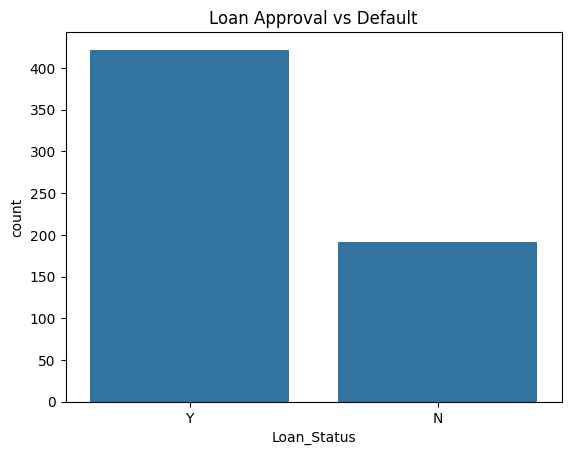

In [ ]:
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval vs Default")
plt.show()


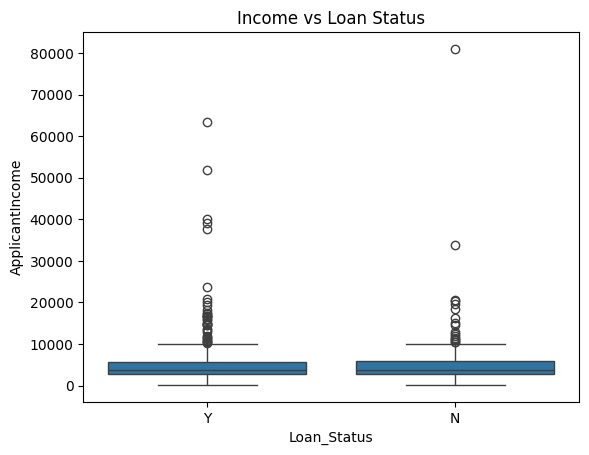

In [ ]:
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.title("Income vs Loan Status")
plt.show()


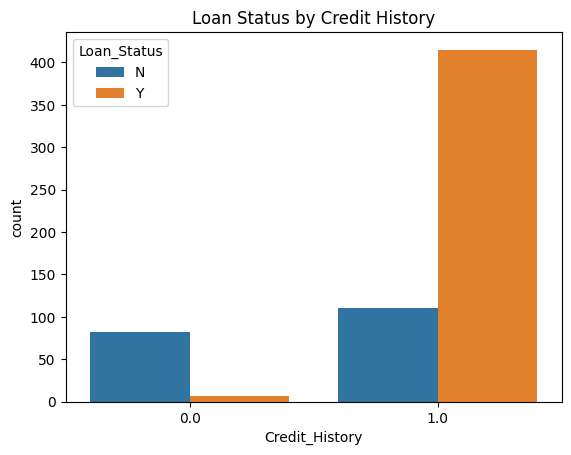

In [ ]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title("Loan Status by Credit History")
plt.show()


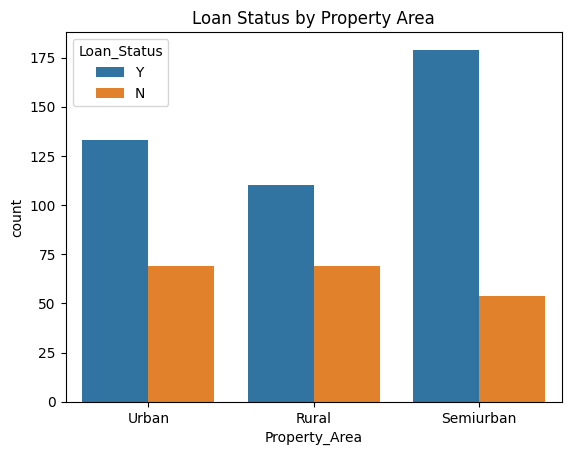

In [ ]:
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)
plt.title("Loan Status by Property Area")
plt.show()


Feature Engineering

In [ ]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['EMI'] = df['LoanAmount'] / df['Loan_Amount_Term']
df['EMI_Income_Ratio'] = df['EMI'] / df['Total_Income']


Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])


Model Building

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:

y_pred = model.predict(X_test)

Evaluation

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7886178861788617
[[18 25]
 [ 1 79]]
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



Feature Importance

In [ ]:
importance = pd.Series(
    model.coef_[0],
    index=X.columns
).sort_values(ascending=False)

importance


,0
Credit_History,3.132637
Married,0.530922
Property_Area,0.086075
Self_Employed,0.064292
Dependents,0.040984
Loan_ID,0.000428
ApplicantIncome,0.000015
Total_Income,-0.000020
CoapplicantIncome,-0.000034
EMI_Income_Ratio,-0.000341


**Key Feature Interpretations**

Credit_History
Customers with a good credit history have a significantly lower probability of default.

EMI_Income_Ratio
Higher EMI relative to income increases default risk due to financial burden.

LoanAmount
Larger loan amounts increase repayment pressure, raising default probability.

Total_Income
Higher income provides better repayment capacity, reducing default risk.

Loan_Amount_Term
Longer tenure lowers EMI burden, slightly reducing default risk.

**Rule-Based Risk Explanation (Human-Readable)
High-Risk Customers**

Poor or no credit history

EMI-to-income ratio greater than 40%

Low income with high loan amount

Unstable employment (self-employed)

Low-Risk Customers

Good credit history

EMI-to-income ratio below 30%

Stable income source

Loan amount proportional to income

**Factors That Increase Default Risk**

Poor credit history

High EMI-to-income ratio

Low total income

High loan amount

Employment instability

**Factors That Make a Customer Low-Risk**

Strong repayment history

Lower EMI burden

Higher and stable income

Reasonable loan size

Longer repayment tenure

**Business Insights & Recommendations**

**Top 5 Risk Indicators**

Credit History

EMI-to-Income Ratio

Total Income

Loan Amount

Employment Type




**Loan Approval Recommendations**

*Approve Loans For:*

Applicants with good credit history

EMI ≤ 30–35% of total income

Stable income sources

Reasonable loan amounts

*Reject / Review Loans For:*

Poor credit history

EMI > 40% of income

Low income requesting high loan amount

High-risk employment profiles

**How Banks Can Reduce Default Risk**

Enforce strict credit history validation

Cap EMI-to-income ratio

Use longer loan tenures for high-risk customers

Apply risk-based interest rates

Monitor early repayment behavior

**Policy Suggestions**

Minimum acceptable credit history score

EMI should not exceed 30–35% of income

Set minimum income thresholds

Restrict large loans for low-income applicants